In [1]:
# useful to autoreload the module without restarting the kernel
%load_ext autoreload
%autoreload 2

In [2]:
from mppi import InputFiles as I, Calculators as C, Utilities as U, Parsers as P
from mppi.Calculators import Tools
import matplotlib.pyplot as plt
import numpy as np
import os

# Tutorial of the YamboNLBDParser class

This tutorial describes the usage of th YamboNLDBParser class used to parse the results of a yambo_nl real-time computations

## Test for LiF in the linear response regime with a delta-shaped pulse

We load the ndb produced by yambo_nl for LiF in the linear response regime

In [3]:
file = 'YamboParser_test/nl_results/LiF_lr/ndb.Nonlinear'

In [4]:
data = P.YamboNLDBParser(file)

Parse file : YamboParser_test/nl_results/LiF_lr/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [5]:
data.get_info()

YamboNLDBParser variables structure

 * * * ndb.Nonlinear db data * * * 

Gauge         : length
NE_steps      : 2001
RT_step       : 0.05000000040705151 [fs] 
n_frequencies : 0
n_angles      : 0
NL_initial_versor   : [0. 0. 0.]
NL_damping    : 0.0
RT_bands      : [3 6]
NL_er         : [-1.0000001 -1.0000001] [eV] 
Sencond Order : False
Use Dipoles   : False
QP_ng_SH      : 11017
QP_ng_Sx      : 11017
RAD_LifeTime  : -1.00000000814103 [fs] 
Integrator    : INVINT
Correlation   : IPA

Efield name         : DELTA
Efield versor       : [1. 0. 0.]
Efield Intesity     : 1.553659979614254e-10
Efield Damping      : 0.0
Efield Freq range   : [0.10000001] [ev] 
Efield Initial time : 0.10000000081410303 [fs] 



We plot the components of the polarization

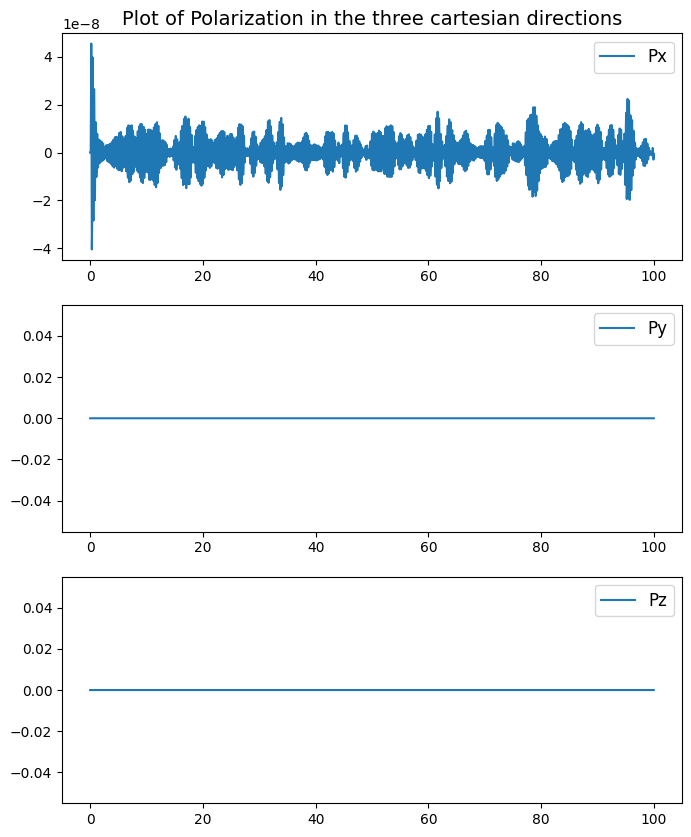

In [7]:
data.plot_polarization()

We can compare this plot with the one extracted from the output file of the same simulation

In [8]:
data_output = P.YamboOutputParser.from_file('YamboParser_test/nl_results/LiF_lr/o-lresponse-bands_3-6-delta.NL_pol_F1')

Parse file YamboParser_test/nl_results/LiF_lr/o-lresponse-bands_3-6-delta.NL_pol_F1


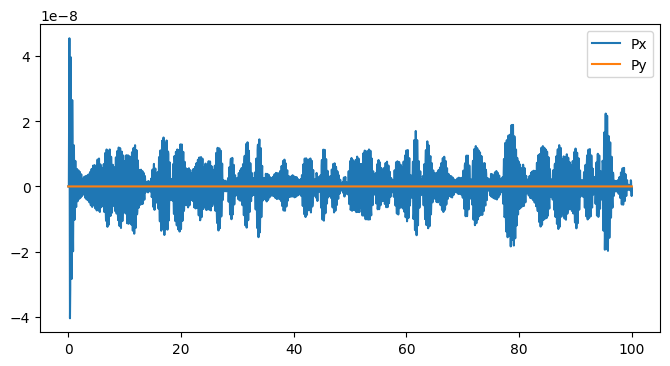

In [9]:
t = data_output['NL_pol_F1']['col1']
Px = data_output['NL_pol_F1']['col2']
Py = data_output['NL_pol_F1']['col3']
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(t,Px,label='Px')
ax1.plot(t,Py,label='Py')
ax1.legend()

We can also show other quantities

In [10]:
E_ext = data.E_ext[0]
E_ext.shape

(3, 2001)

In [11]:
E_ext[0]

masked_array(data=[-0.00000000e+00+0.j, -0.00000000e+00+0.j,
                    1.82604166e-06+0.j, ..., -0.00000000e+00+0.j,
                   -0.00000000e+00+0.j, -0.00000000e+00+0.j],
             mask=False,
       fill_value=(1e+20+0j))

In [12]:
time = data.get_time()

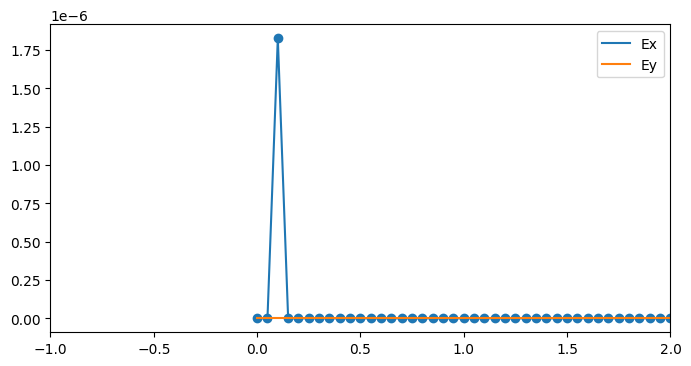

In [13]:
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(time,np.real(E_ext[0]),label='Ex')
ax1.scatter(time,np.real(E_ext[0]))
ax1.plot(time,np.real(E_ext[1]),label='Ey')
ax1.set_xlim(-1,2)
ax1.legend()